In [1]:
# -----------------------------
# Paths + settings
# -----------------------------
import os, random
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 72
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

# Notebook assumed at: .../Net/code/
CODE_DIR = Path.cwd()
NET_DIR  = CODE_DIR.parent
IN_DIR   = NET_DIR / "preprocessing_data"
OUT_DIR  = NET_DIR / "data" / "EN_preproc_single_split"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("CODE_DIR:", CODE_DIR)
print("IN_DIR  :", IN_DIR)
print("OUT_DIR :", OUT_DIR)

# Single split settings
TEST_SIZE = 0.30
SEED = 340

# Fusion mode:
#   "concat"         -> early fusion, feature count increases (~576)
#   "mean"           -> aggregate: mean across modalities (feature count ~144)
#   "mean_std"       -> aggregate: mean + std across modalities (feature count ~288)
FUSION_MODE = "concat"

# SVM-L1 feature selection
SVM_C = 15
EPS = 1e-6

# Selection rule:
#   "positive" -> keep coef > 0  (what you asked)
#   "nonzero"  -> keep |coef| > EPS (recommended)
SELECT_RULE = "nonzero"

CODE_DIR: c:\Users\junse\Documents\research\UPENN-GBM\All_mortality\EN\code
IN_DIR  : c:\Users\junse\Documents\research\UPENN-GBM\All_mortality\EN\preprocessing_data
OUT_DIR : c:\Users\junse\Documents\research\UPENN-GBM\All_mortality\EN\data\EN_preproc_single_split


In [2]:
# -----------------------------
# Load EN radiomics (4 modalities) + clinical
# -----------------------------
flair = pd.read_csv(IN_DIR / "Radiomic_Features_CaPTk_segm_FLAIR_ET.csv")
t1    = pd.read_csv(IN_DIR / "Radiomic_Features_CaPTk_segm_T1_ET.csv")
t1gd  = pd.read_csv(IN_DIR / "Radiomic_Features_CaPTk_segm_T1GD_ET.csv")
t2    = pd.read_csv(IN_DIR / "Radiomic_Features_CaPTk_segm_T2_ET.csv")

clin  = pd.read_csv(IN_DIR / "UPENN-GBM_clinical_info_v2.1.csv")

print("Radiomics shapes:", flair.shape, t1.shape, t1gd.shape, t2.shape)
print("Clinical shape:", clin.shape)
print("Clinical columns:", list(clin.columns))

Radiomics shapes: (231, 145) (231, 145) (231, 145) (231, 145)
Clinical shape: (671, 12)
Clinical columns: ['ID', 'Gender', 'Age_at_scan_years', 'Survival_from_surgery_days_UPDATED', 'Survival_Status', 'Survival_Censor', 'IDH1', 'MGMT', 'KPS', 'GTR_over90percent', 'Time_since_baseline_preop', 'PsP_TP_score']


In [3]:
# ============================================
# Cell 1) Load + Sanity checks (ET, 3 modalities)
# ============================================

ROI_TAG = "ET"  # this dataset is ET

def assert_prefix(df: pd.DataFrame, prefix: str, name: str):
    assert df.columns[0] == "SubjectID", f"{name}: first column must be SubjectID"
    bad = [c for c in df.columns[1:] if not c.startswith(prefix)]
    if bad:
        raise ValueError(f"{name}: columns not starting with {prefix} (examples): {bad[:5]}")

def strip_prefix(cols, prefix):
    return [c[len(prefix):] for c in cols]

# Prefix checks
assert_prefix(t1,   f"T1_{ROI_TAG}_",   f"T1_{ROI_TAG}")
assert_prefix(t1gd, f"T1GD_{ROI_TAG}_", f"T1GD_{ROI_TAG}")
assert_prefix(t2,   f"T2_{ROI_TAG}_",   f"T2_{ROI_TAG}")
print(f"✅ {ROI_TAG} prefixes OK")

# Check SubjectID sets match
ids0 = set(t1["SubjectID"].astype(str))
for name, df in [("T1GD", t1gd), ("T2", t2)]:
    ids = set(df["SubjectID"].astype(str))
    if ids != ids0:
        raise ValueError(f"SubjectID mismatch: {name} differs from T1 (diff={len(ids ^ ids0)})")
print(f"✅ SubjectID sets match across modalities (n={len(ids0)})")

# Check base feature names identical across modalities
base_feats = strip_prefix(t1.columns[1:], f"T1_{ROI_TAG}_")

feats_t1gd = strip_prefix(t1gd.columns[1:], f"T1GD_{ROI_TAG}_")
feats_t2   = strip_prefix(t2.columns[1:],   f"T2_{ROI_TAG}_")

if feats_t1gd != base_feats:
    raise ValueError("Base feature mismatch between T1 and T1GD")
if feats_t2 != base_feats:
    raise ValueError("Base feature mismatch between T1 and T2")

print("✅ Base feature list identical across T1 / T1GD / T2")
print("T1 shape:", t1.shape, "T1GD shape:", t1gd.shape, "T2 shape:", t2.shape)


✅ ET prefixes OK
✅ SubjectID sets match across modalities (n=231)
✅ Base feature list identical across T1 / T1GD / T2
T1 shape: (231, 145) T1GD shape: (231, 145) T2 shape: (231, 145)


In [4]:
# ============================================
# Cell 2) Build feature matrix (concat / mean / mean_std)
# ============================================

FUSION_MODE = "concat"  # "concat" or "mean" or "mean_std"

dfs = {"T1": t1, "T1GD": t1gd, "T2": t2}
modalities = ["T1", "T1GD", "T2"]

# (Optional but safe) sort by SubjectID so row order is consistent
for m in modalities:
    dfs[m] = dfs[m].copy()
    dfs[m]["SubjectID"] = dfs[m]["SubjectID"].astype(str)
    dfs[m] = dfs[m].sort_values("SubjectID").reset_index(drop=True)

if FUSION_MODE == "concat":
    # Early fusion: merge on SubjectID (safest)
    all_roi = (
        dfs["T1"]
        .merge(dfs["T1GD"], on="SubjectID", how="inner")
        .merge(dfs["T2"],   on="SubjectID", how="inner")
    )
    print("Fusion=concat, shape:", all_roi.shape)

elif FUSION_MODE in ("mean", "mean_std"):
    base_feats = strip_prefix(dfs["T1"].columns[1:], f"T1_{ROI_TAG}_")
    out = pd.DataFrame({"SubjectID": dfs["T1"]["SubjectID"].astype(str)})

    # Aggregate across modalities for each base feature
    for bf in base_feats:
        M = np.vstack([
            dfs[m][f"{m}_{ROI_TAG}_{bf}"].to_numpy()
            for m in modalities
        ]).T  # shape: (n, 3)

        out[f"ALL_{ROI_TAG}_{bf}_mean"] = np.nanmean(M, axis=1)

        if FUSION_MODE == "mean_std":
            out[f"ALL_{ROI_TAG}_{bf}_std"] = np.nanstd(M, axis=1)

    all_roi = out
    print(f"Fusion={FUSION_MODE}, shape:", all_roi.shape)

else:
    raise ValueError("Unknown FUSION_MODE")


Fusion=concat, shape: (231, 433)


In [5]:
# ============================================
# Cell 3) Merge clinical + build X/y (binary MGMT) safely
# ============================================

# Assumes you already loaded clin as a DataFrame.
# Required columns: ID, MGMT
if "ID" not in clin.columns:
    raise ValueError("Clinical file missing 'ID' column")
if "MGMT" not in clin.columns:
    raise ValueError("Clinical file missing 'MGMT' column")

# Ensure string IDs, and de-duplicate clinical IDs if needed
clin2 = clin.copy()
clin2["ID"] = clin2["ID"].astype(str)
clin2 = clin2.drop_duplicates(subset=["ID"], keep="first")

all_roi2 = all_roi.copy()
all_roi2["SubjectID"] = all_roi2["SubjectID"].astype(str)

merged = all_roi2.merge(clin2[["ID", "MGMT"]], left_on="SubjectID", right_on="ID", how="left")

print("MGMT raw counts:")
print(merged["MGMT"].value_counts(dropna=False))

# Keep only Methylated / Unmethylated
df_bin = merged[merged["MGMT"].isin(["Methylated", "Unmethylated"])].copy()
print("Binary-usable n:", len(df_bin))
print("Binary counts:", df_bin["MGMT"].value_counts().to_dict())

y = df_bin["MGMT"].map({"Methylated": 1, "Unmethylated": 0}).astype(int)

# IMPORTANT: X should contain ONLY feature columns from all_roi (avoid leaking clinical numeric cols)
feature_cols = [c for c in all_roi2.columns if c != "SubjectID"]
X = df_bin[feature_cols].copy()

# Optional cleanup
X = X.select_dtypes(include=[np.number]).copy()   # in case SubjectID accidentally slipped in
X = X.dropna(axis=1, how="all")
X = X.loc[:, X.nunique(dropna=True) > 1]

ids = df_bin["SubjectID"].astype(str).reset_index(drop=True)

print("X shape:", X.shape, "y shape:", y.shape, "ids n:", len(ids))


MGMT raw counts:
MGMT
Not Available    163
Unmethylated      37
Methylated        22
Indeterminate      9
Name: count, dtype: int64
Binary-usable n: 59
Binary counts: {'Unmethylated': 37, 'Methylated': 22}
X shape: (59, 405) y shape: (59,) ids n: 59


In [ ]:
# -----------------------------
# Single stratified 70/30 split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, ids,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train y:", y_train.value_counts().to_dict(), "Test y:", y_test.value_counts().to_dict())

# Save split IDs
pd.Series(id_train).to_csv(OUT_DIR / "train_ids.csv", index=False, header=["SubjectID"])
pd.Series(id_test).to_csv(OUT_DIR / "test_ids.csv", index=False, header=["SubjectID"])

Train: (41, 405) Test: (18, 405)
Train y: {0: 26, 1: 15} Test y: {0: 11, 1: 7}


In [ ]:
# -----------------------------
# SVM-L1 feature selection on TRAIN only
# Keep features based on coefficients
# -----------------------------

svm_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", LinearSVC(
        penalty="l1",
        dual=False,
        C=SVM_C,
        random_state=SEED,
        max_iter=30000
    ))
])

svm_l1.fit(X_train, y_train)

coef = svm_l1.named_steps["svc"].coef_.ravel()

if SELECT_RULE == "positive":
    mask = coef > 0
elif SELECT_RULE == "nonzero":
    mask = np.abs(coef) > EPS
else:
    raise ValueError("Unknown SELECT_RULE")

selected = X_train.columns[mask].tolist()
print("Original #features:", X_train.shape[1])
print("Selected #features:", len(selected))

if len(selected) == 0:
    raise ValueError("SVM selected 0 features. Try larger C or use nonzero rule.")

X_train_sel = X_train[selected].copy()
X_test_sel  = X_test[selected].copy()

# Save selected feature names
pd.Series(selected).to_csv(OUT_DIR / "selected_features_svm_l1.csv", index=False, header=["feature"])

# Save selected matrices
X_train_sel.to_csv(OUT_DIR / "X_train_sel.csv", index=False)
X_test_sel.to_csv(OUT_DIR / "X_test_sel.csv", index=False)
pd.Series(y_train).to_csv(OUT_DIR / "y_train.csv", index=False, header=["y"])
pd.Series(y_test).to_csv(OUT_DIR / "y_test.csv", index=False, header=["y"])

Original #features: 405
Selected #features: 37


In [8]:
# =========================
# 1) Load data (from your preprocessing outputs)
# =========================

# Notebook assumed at: .../Net/code/
CODE_DIR = Path.cwd()
NET_DIR  = CODE_DIR.parent

# Change this if your folder name is different
DATA_DIR = NET_DIR / "data" / "EN_preproc_single_split"

# Load SVM-selected features (recommended to make RFECV feasible)
X_train = pd.read_csv(DATA_DIR / "X_train_sel.csv")
X_test  = pd.read_csv(DATA_DIR / "X_test_sel.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["y"]
y_test  = pd.read_csv(DATA_DIR / "y_test.csv")["y"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.value_counts().to_dict())
print("y_test :", y_test.value_counts().to_dict())

X_train: (41, 37)
X_test : (18, 37)
y_train: {0: 26, 1: 15}
y_test : {0: 11, 1: 7}


In [9]:
# =========================
# 2) RFECV setup
# =========================
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV

def make_rf(seed: int = 42):
    """RandomForest for RFECV (fixed hyperparameters)."""
    return RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=2,
        bootstrap=True,
        n_jobs=-1,              # parallel OK; not strictly deterministic across all systems
        random_state=seed,
    )

rf_for_rfe = make_rf(seed=RANDOM_STATE)

cv_sel = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

rfecv = RFECV(
    estimator=rf_for_rfe,
    step=1,                    # remove 1 feature each step (can be slow if many features)
    cv=cv_sel,
    scoring="roc_auc",
    n_jobs=-1,
    min_features_to_select=1,
)


In [10]:
# =========================
# 3) Fit RFECV on TRAIN
# =========================
rfecv.fit(X_train, y_train)

print("Number of features in X_train:", rfecv.n_features_in_)
print("Best number of features according to RFECV:", rfecv.n_features_)

support_mask = rfecv.support_
selected_idx = np.where(support_mask)[0]
selected_features = list(X_train.columns[selected_idx])

print("\nSelected feature indices (RFECV best subset):")
print(selected_idx)

print("\nSelected feature names (first 30):")
print(selected_features[:30])

Number of features in X_train: 37
Best number of features according to RFECV: 30

Selected feature indices (RFECV best subset):
[ 0  1  3  4  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 23 26 27 29 30
 31 32 33 34 35 36]

Selected feature names (first 30):
['T1_ET_Intensity_MeanAbsoluteDeviation', 'T1_ET_Intensity_Variance', 'T1_ET_Histogram_Bins-16_Bins-16_Bin-5_Probability', 'T1_ET_Histogram_Bins-16_Bins-16_Bin-7_Probability', 'T1_ET_Histogram_Bins-16_Bins-16_MedianAbsoluteDeviation', 'T1_ET_Morphologic_Flatness', 'T1_ET_Morphologic_Roundness', 'T1_ET_NGTDM_Complexity', 'T1GD_ET_Intensity_Mode', 'T1GD_ET_Histogram_Bins-16_Bins-16_Bin-11_Probability', 'T1GD_ET_Histogram_Bins-16_Bins-16_Bin-1_Frequency', 'T1GD_ET_Morphologic_Flatness', 'T1GD_ET_Morphologic_Roundness', 'T1GD_ET_GLRLM_Bins-16_Radius-1_ShortRunEmphasis', 'T1GD_ET_GLSZM_Bins-16_Radius-1_LowGreyLevelEmphasis', 'T1GD_ET_GLSZM_Bins-16_Radius-1_SmallZoneLowGreyLevelEmphasis', 'T1GD_ET_GLSZM_Bins-16_Radius-1_ZoneSizeEntropy', '

Best (<=20): n=18, mean CV AUC=0.8000


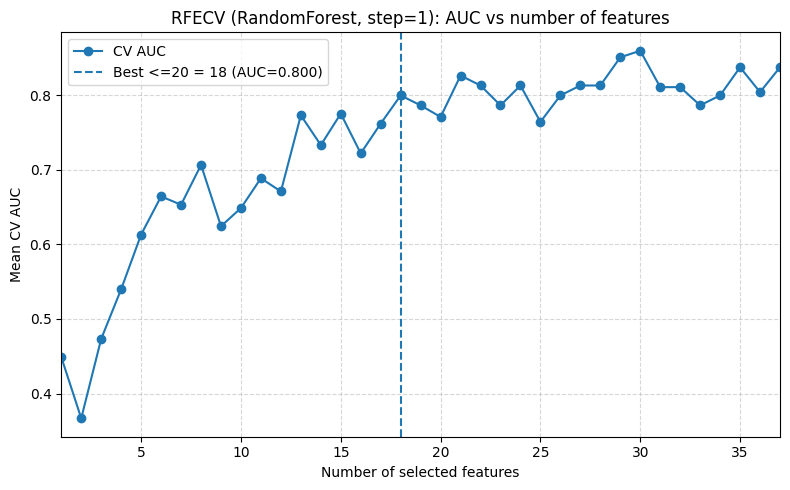

In [11]:
# =========================
# Plot AUC vs number of selected features
# + choose BEST UNDER 20 features
# =========================
try:
    mean_scores = rfecv.cv_results_["mean_test_score"]
    n_features  = rfecv.cv_results_["n_features"]
except Exception:
    mean_scores = rfecv.grid_scores_
    n_total = rfecv.n_features_in_
    min_feat = rfecv.min_features_to_select
    step = rfecv.step
    n_features = np.arange(n_total, min_feat - 1, -step)[::-1]

n_features_arr = np.asarray(n_features)
mean_scores_arr = np.asarray(mean_scores)

mask_20 = n_features_arr <= 20
if not np.any(mask_20):
    raise ValueError("No points with n_features <= 20 (unexpected with step=1).")

best_idx_under20 = np.argmax(mean_scores_arr[mask_20])
best_n_under20 = n_features_arr[mask_20][best_idx_under20]
best_auc_under20 = mean_scores_arr[mask_20][best_idx_under20]

print(f"Best (<=20): n={best_n_under20}, mean CV AUC={best_auc_under20:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(n_features_arr, mean_scores_arr, marker="o", label="CV AUC")

# Mark best under 20 (this is what you want)
plt.axvline(
    x=best_n_under20,
    linestyle="--",
    label=f"Best <=20 = {best_n_under20} (AUC={best_auc_under20:.3f})"
)
plt.scatter([best_n_under20], [best_auc_under20], marker="o")

plt.xlabel("Number of selected features")
plt.ylabel("Mean CV AUC")
plt.title("RFECV (RandomForest, step=1): AUC vs number of features")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(1, X_train.shape[1])
plt.legend()
plt.tight_layout()
plt.show()

Train AUC: 1.0000
Test  AUC: 0.4935


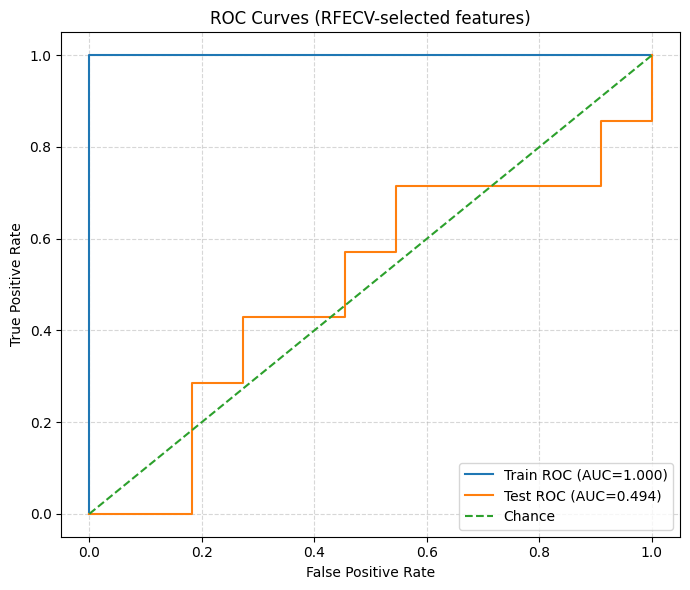

In [12]:
# =========================
# 5) Train final RF on RFECV-selected features and plot ROC (Train & Test)
# =========================

# Reduce X to selected features
X_train_rfe = X_train[selected_features].copy()
X_test_rfe  = X_test[selected_features].copy()

# Fit final model on TRAIN only
rf_final = make_rf(seed=RANDOM_STATE)
rf_final.fit(X_train_rfe, y_train)

# Predict probabilities
p_train = rf_final.predict_proba(X_train_rfe)[:, 1]
p_test  = rf_final.predict_proba(X_test_rfe)[:, 1]

# AUCs
auc_train = roc_auc_score(y_train, p_train)
auc_test  = roc_auc_score(y_test, p_test)

print(f"Train AUC: {auc_train:.4f}")
print(f"Test  AUC: {auc_test:.4f}")

# ROC curves
fpr_tr, tpr_tr, _ = roc_curve(y_train, p_train)
fpr_te, tpr_te, _ = roc_curve(y_test,  p_test)

plt.figure(figsize=(7, 6))
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={auc_train:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={auc_test:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (RFECV-selected features)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Number of features in X_train: 37
RFECV-chosen #features: 37


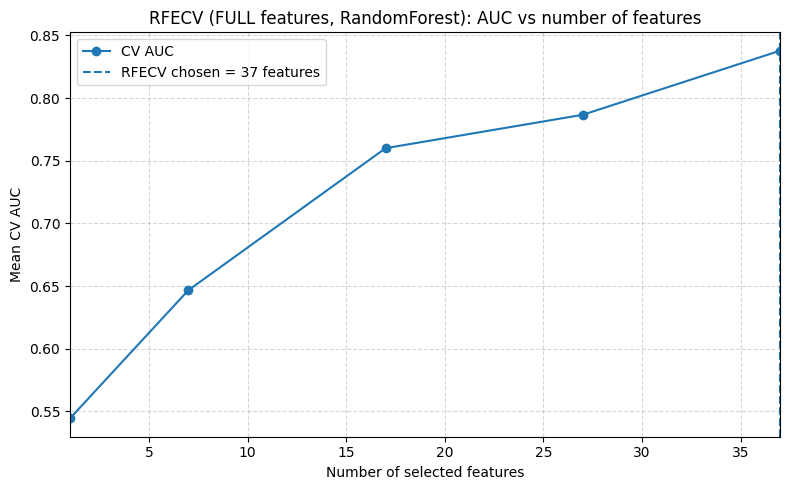

In [13]:
# =========================
# (FULL) RFECV setup for a quick snapshot
# Assumes:
#   - X_train, y_train already exist (FULL features, before SVM)
#   - RANDOM_STATE already defined
#   - imports already done (RandomForestClassifier, StratifiedKFold, RFECV, plt)
# =========================

def make_rf(seed: int):
    return RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=2,
        bootstrap=True,
        n_jobs=-1,
        random_state=seed,
    )

rf_for_rfe_full = make_rf(seed=RANDOM_STATE)

cv_sel_full = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# NOTE: step=1 can be very slow with 500+ features.
# For a "snapshot curve", step=10 (or 20) is usually enough.
rfecv_full = RFECV(
    estimator=rf_for_rfe_full,
    step=10,
    cv=cv_sel_full,
    scoring="roc_auc",
    n_jobs=-1,
    min_features_to_select=1,
)
# =========================
# Fit RFECV on TRAIN (FULL)
# =========================

rfecv_full.fit(X_train, y_train)

print("Number of features in X_train:", rfecv_full.n_features_in_)
print("RFECV-chosen #features:", rfecv_full.n_features_)
# =========================
# Plot AUC vs number of selected features
# =========================

try:
    # Newer scikit-learn
    mean_scores = rfecv_full.cv_results_["mean_test_score"]
    n_features  = rfecv_full.cv_results_["n_features"]
except Exception:
    # Older scikit-learn fallback
    mean_scores = rfecv_full.grid_scores_
    n_total = rfecv_full.n_features_in_
    min_feat = rfecv_full.min_features_to_select
    step = rfecv_full.step
    n_features = np.arange(n_total, min_feat - 1, -step)[::-1]

n_features_arr = np.asarray(n_features)
mean_scores_arr = np.asarray(mean_scores)

plt.figure(figsize=(8, 5))
plt.plot(n_features_arr, mean_scores_arr, marker="o", label="CV AUC")

# Optional: show RFECV's chosen number of features
plt.axvline(
    x=rfecv_full.n_features_,
    linestyle="--",
    label=f"RFECV chosen = {rfecv_full.n_features_} features"
)

plt.xlabel("Number of selected features")
plt.ylabel("Mean CV AUC")
plt.title("RFECV (FULL features, RandomForest): AUC vs number of features")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(1, X_train.shape[1])
plt.legend()
plt.tight_layout()
plt.show()